# Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Assignment 4 — AI/ML**

**Objective:** Build a K-Nearest Neighbors classifier to predict whether a breast
tumor is Malignant (M) or Benign (B) from diagnostic measurements.

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) Dataset (Kaggle)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv("breast_cancer.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


**Feature identification**

| Type | Columns |
|---|---|
| Numerical features | 30 diagnostic measurements: `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`, ... (mean, standard-error, and "worst" values of each cell-nucleus characteristic) |
| Target variable | `diagnosis` (M = malignant, B = benign) |
| Dropped | `id` (identifier, not predictive); `Unnamed: 32` (empty column, artifact of the source CSV's trailing comma) |


## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()[df.isnull().sum() > 0]


Unnamed: 32    569
dtype: int64

In [6]:
# Remove unnecessary columns: id (identifier) and Unnamed: 32 (fully empty column)
df = df.drop(columns=['id', 'Unnamed: 32'])
print("Shape after dropping unnecessary columns:", df.shape)


Shape after dropping unnecessary columns: (569, 31)


In [7]:
# Encode the target variable: B -> 0, M -> 1
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print("Classes:", list(le.classes_), "-> encoded as", list(le.transform(le.classes_)))
df['diagnosis'].value_counts()


Classes: ['B', 'M'] -> encoded as [np.int64(0), np.int64(1)]


diagnosis
0    357
1    212
Name: count, dtype: int64

In [8]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 80/20 split, stratified to preserve the benign/malignant ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


In [9]:
# Standardize the feature values (fit on train, apply to both) -
# essential for KNN since it's a distance-based algorithm
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Task 3: Model Development

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred[:10]


array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

## Task 4: Model Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.9561
Precision: 0.9744
Recall:    0.9048
F1-Score:  0.9383


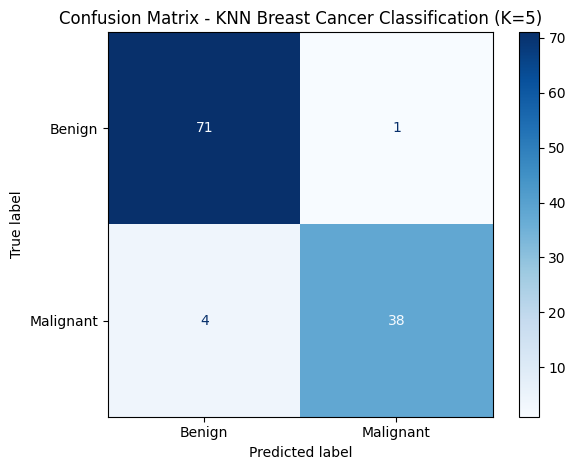

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - KNN Breast Cancer Classification (K=5)")
plt.tight_layout()
plt.show()


In [13]:
# Demonstrate why scaling matters for KNN: same model, same split, but on
# UN-scaled features
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

print(f"Accuracy with scaling:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy without scaling: {accuracy_score(y_test, y_pred_unscaled):.4f}")


Accuracy with scaling:    0.9561
Accuracy without scaling: 0.9123


### Observations

1. **The scaled KNN model performs strongly**, with accuracy ≈ 0.956 and precision ≈
   0.974 — when it predicts malignant, it's right almost 97% of the time, which matters
   a lot in a diagnostic setting where false alarms lead to unnecessary follow-up tests.
2. **Recall (≈ 0.905) is slightly lower than precision**, meaning the confusion matrix
   shows a few malignant cases classified as benign (false negatives) — the more
   clinically costly type of error, since a missed cancer diagnosis delays treatment.
3. **Removing feature scaling drops accuracy** (from ≈ 0.956 to ≈ 0.912) on the exact
   same split, which directly demonstrates why standardization matters for a
   distance-based algorithm like KNN: features like `area_mean` (values in the
   hundreds/thousands) would otherwise dominate the Euclidean distance calculation over
   features like `smoothness_mean` (values around 0.1), even though both can be equally
   informative.


## Task 5: Conclusion

This project used a K-Nearest Neighbors classifier (K=5) to distinguish malignant
from benign breast tumors using 30 diagnostic measurements derived from cell nuclei
images. After dropping the non-predictive `id` and empty `Unnamed: 32` columns, encoding
the diagnosis, standardizing the features, and splitting the data 80/20, the model
reached about 95.6% accuracy, with precision of 0.97 and recall of 0.90 on the test set.
Feature scaling is critical for KNN because the algorithm classifies a new point by the
Euclidean distance to its nearest neighbors, and without scaling, features with larger
raw numeric ranges (like `area_mean`, in the hundreds) would dominate that distance
calculation over features with small ranges (like `smoothness_mean`, around 0.1) even if
the latter is just as diagnostically important — standardizing puts every feature on the
same scale so each contributes fairly. A key limitation of KNN is that it has no explicit
training phase and instead must compute distances to every training point at prediction
time, making it computationally expensive and slow to scale to very large datasets or
high-dimensional feature spaces, where the notion of "nearest neighbor" also becomes
less meaningful (the curse of dimensionality).
